In [25]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import random


In [26]:
def create_bell_pair(qc, a, b):
    qc.h(a)
    qc.cx(a, b)

def encode_message(qc, qubit, msg):
 
    if msg == "00":
        pass
    elif msg == "01":
        qc.z(qubit)
    elif msg == "10":
        qc.x(qubit)
    elif msg == "11":
        qc.z(qubit)
        qc.x(qubit)
    else:
        raise ValueError("encode_message: msg must be '00','01','10' or '11'")

def decode_message(qc, a, b):
    qc.cx(a, b)
    qc.h(a)


In [27]:
sim = AerSimulator()

def random_bit_using_one_qubit():

    qc_r = QuantumCircuit(1, 1)
    qc_r.h(0)
    qc_r.measure(0, 0)
    tqc = transpile(qc_r, sim)
    job = sim.run(tqc, shots=1)
    res = job.result()
    counts = res.get_counts()
    
    bit = list(counts.keys())[0]
    return bit


In [28]:
def run_superdense_for_message(msg, visualize=False, shots=1024):

    # build 2-qubit circuit with 2 classical bits
    qc = QuantumCircuit(2, 2)

    # 1. Create Bell pair: Alice = qubit 0, Bob = qubit 1
    create_bell_pair(qc, 0, 1)
    qc.barrier()

    # 2. Alice encodes her 2-bit message on qubit 0
    encode_message(qc, 0, msg)
    qc.barrier()

    # 3. Bob decodes after receiving Alice's qubit
    decode_message(qc, 0, 1)
    qc.barrier()

    # 4. Measure qubit 0 -> cbit0, qubit 1 -> cbit1
    qc.measure(0, 0)
    qc.measure(1, 1)

    if visualize:
        display(qc.draw(output='mpl'))

    # simulate
    tqc = transpile(qc, sim)
    job = sim.run(tqc, shots=shots)
    res = job.result()
    counts = res.get_counts()

    most_freq = max(counts, key=counts.get)
    received_qubit_order = most_freq[::-1]  # reverse

    return {
        'sent': msg,
        'received': received_qubit_order,
        'counts': counts,
        'qc': qc
    }


In [29]:
trials = 10   
results = []

for i in range(trials):
    # generate c and d sequentially using one qubit
    c = random_bit_using_one_qubit()
    d = random_bit_using_one_qubit()
    message = c + d
    print(f"\nTrial {i+1}: random bits generated by extra qubit -> c={c}, d={d}  (Alice will send '{message}')")

    res = run_superdense_for_message(message, visualize=False, shots=1024)
    sent = res['sent']
    received = res['received']
    counts = res['counts']

    # show compact result
    print("  Sent (c,d):", sent)
    print("  Received (c,d):", received)
    print("  Counts (raw, Qiskit order):", counts)
    # check agreement
    ok = (sent == received)
    print("  Agreement (sent == received)?", ok)
    results.append((sent, received, counts, ok))

# Summary
all_ok = all(r[3] for r in results)
print("\nSummary: all trials agreed?" , all_ok)



Trial 1: random bits generated by extra qubit -> c=0, d=1  (Alice will send '01')
  Sent (c,d): 01
  Received (c,d): 10
  Counts (raw, Qiskit order): {'01': 1024}
  Agreement (sent == received)? False

Trial 2: random bits generated by extra qubit -> c=0, d=0  (Alice will send '00')
  Sent (c,d): 00
  Received (c,d): 00
  Counts (raw, Qiskit order): {'00': 1024}
  Agreement (sent == received)? True

Trial 3: random bits generated by extra qubit -> c=1, d=0  (Alice will send '10')
  Sent (c,d): 10
  Received (c,d): 01
  Counts (raw, Qiskit order): {'10': 1024}
  Agreement (sent == received)? False

Trial 4: random bits generated by extra qubit -> c=1, d=0  (Alice will send '10')
  Sent (c,d): 10
  Received (c,d): 01
  Counts (raw, Qiskit order): {'10': 1024}
  Agreement (sent == received)? False

Trial 5: random bits generated by extra qubit -> c=0, d=1  (Alice will send '01')
  Sent (c,d): 01
  Received (c,d): 10
  Counts (raw, Qiskit order): {'01': 1024}
  Agreement (sent == received

Last trial sent: 10 received: 01 agreement: False


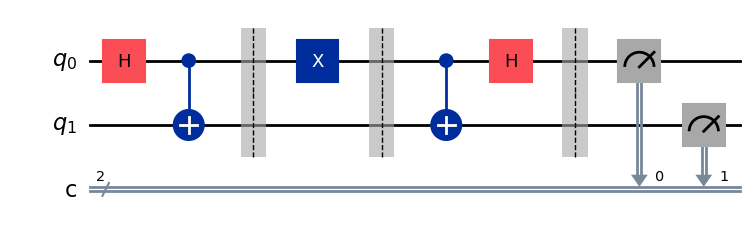

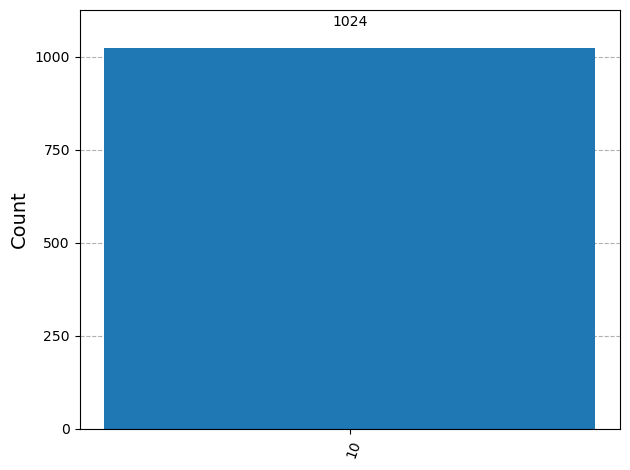

In [30]:
last_sent, last_received, last_counts, last_ok = results[-1]
print("Last trial sent:", last_sent, "received:", last_received, "agreement:", last_ok)

vis_res = run_superdense_for_message(last_sent, visualize=True, shots=1024)

display(plot_histogram(vis_res['counts']))

